# Projeto Redes Neurais

**Autor:** Celso Daniel


## Preparação dos Dados


### Importando Bibliotecas


In [207]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split,
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
)
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

### Carregando os Dados para um DataFrame


In [208]:
df = pd.read_csv("data/pima.csv", sep=";")

In [209]:
print(f"Total de linhas: {len(df)}")
print(f"Total de colunas: {len(df.columns)}")

Total de linhas: 768
Total de colunas: 9


In [210]:
display(df.head(5))

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable (0 or 1)
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [211]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                                                                    Non-Null Count  Dtype  
---  ------                                                                    --------------  -----  
 0   Number of times pregnant                                                  768 non-null    int64  
 1   Plasma glucose concentration a 2 hours in an oral glucose tolerance test  768 non-null    int64  
 2   Diastolic blood pressure (mm Hg)                                          768 non-null    int64  
 3   Triceps skin fold thickness (mm)                                          768 non-null    int64  
 4   2-Hour serum insulin (mu U/ml)                                            768 non-null    int64  
 5   Body mass index (weight in kg/(height in m)^2)                            768 non-null    float64
 6   Diabetes pedigree function                                                768 

,Number of times pregnant,Plasma glucose concentration a 2 hours in an oral glucose tolerance test,Diastolic blood pressure (mm Hg),Triceps skin fold thickness (mm),2-Hour serum insulin (mu U/ml),Body mass index (weight in kg/(height in m)^2),Diabetes pedigree function,Age (years),Class variable (0 or 1)
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [212]:
cols = {
    "Number of times pregnant": "pregnancies",
    "Plasma glucose concentration a 2 hours in an oral glucose tolerance test": "glucose",
    "Diastolic blood pressure (mm Hg)": "blood_pressure",
    "Triceps skin fold thickness (mm)": "skin_thickness",
    "2-Hour serum insulin (mu U/ml)": "insulin",
    "Body mass index (weight in kg/(height in m)^2)": "bmi",
    "Diabetes pedigree function": "pedigree_function",
    "Age (years)": "age",
    "Class variable (0 or 1)": "diabetes",
}

df = df.rename(columns=cols)

## Análise Exploratória


### Análise de Outliers


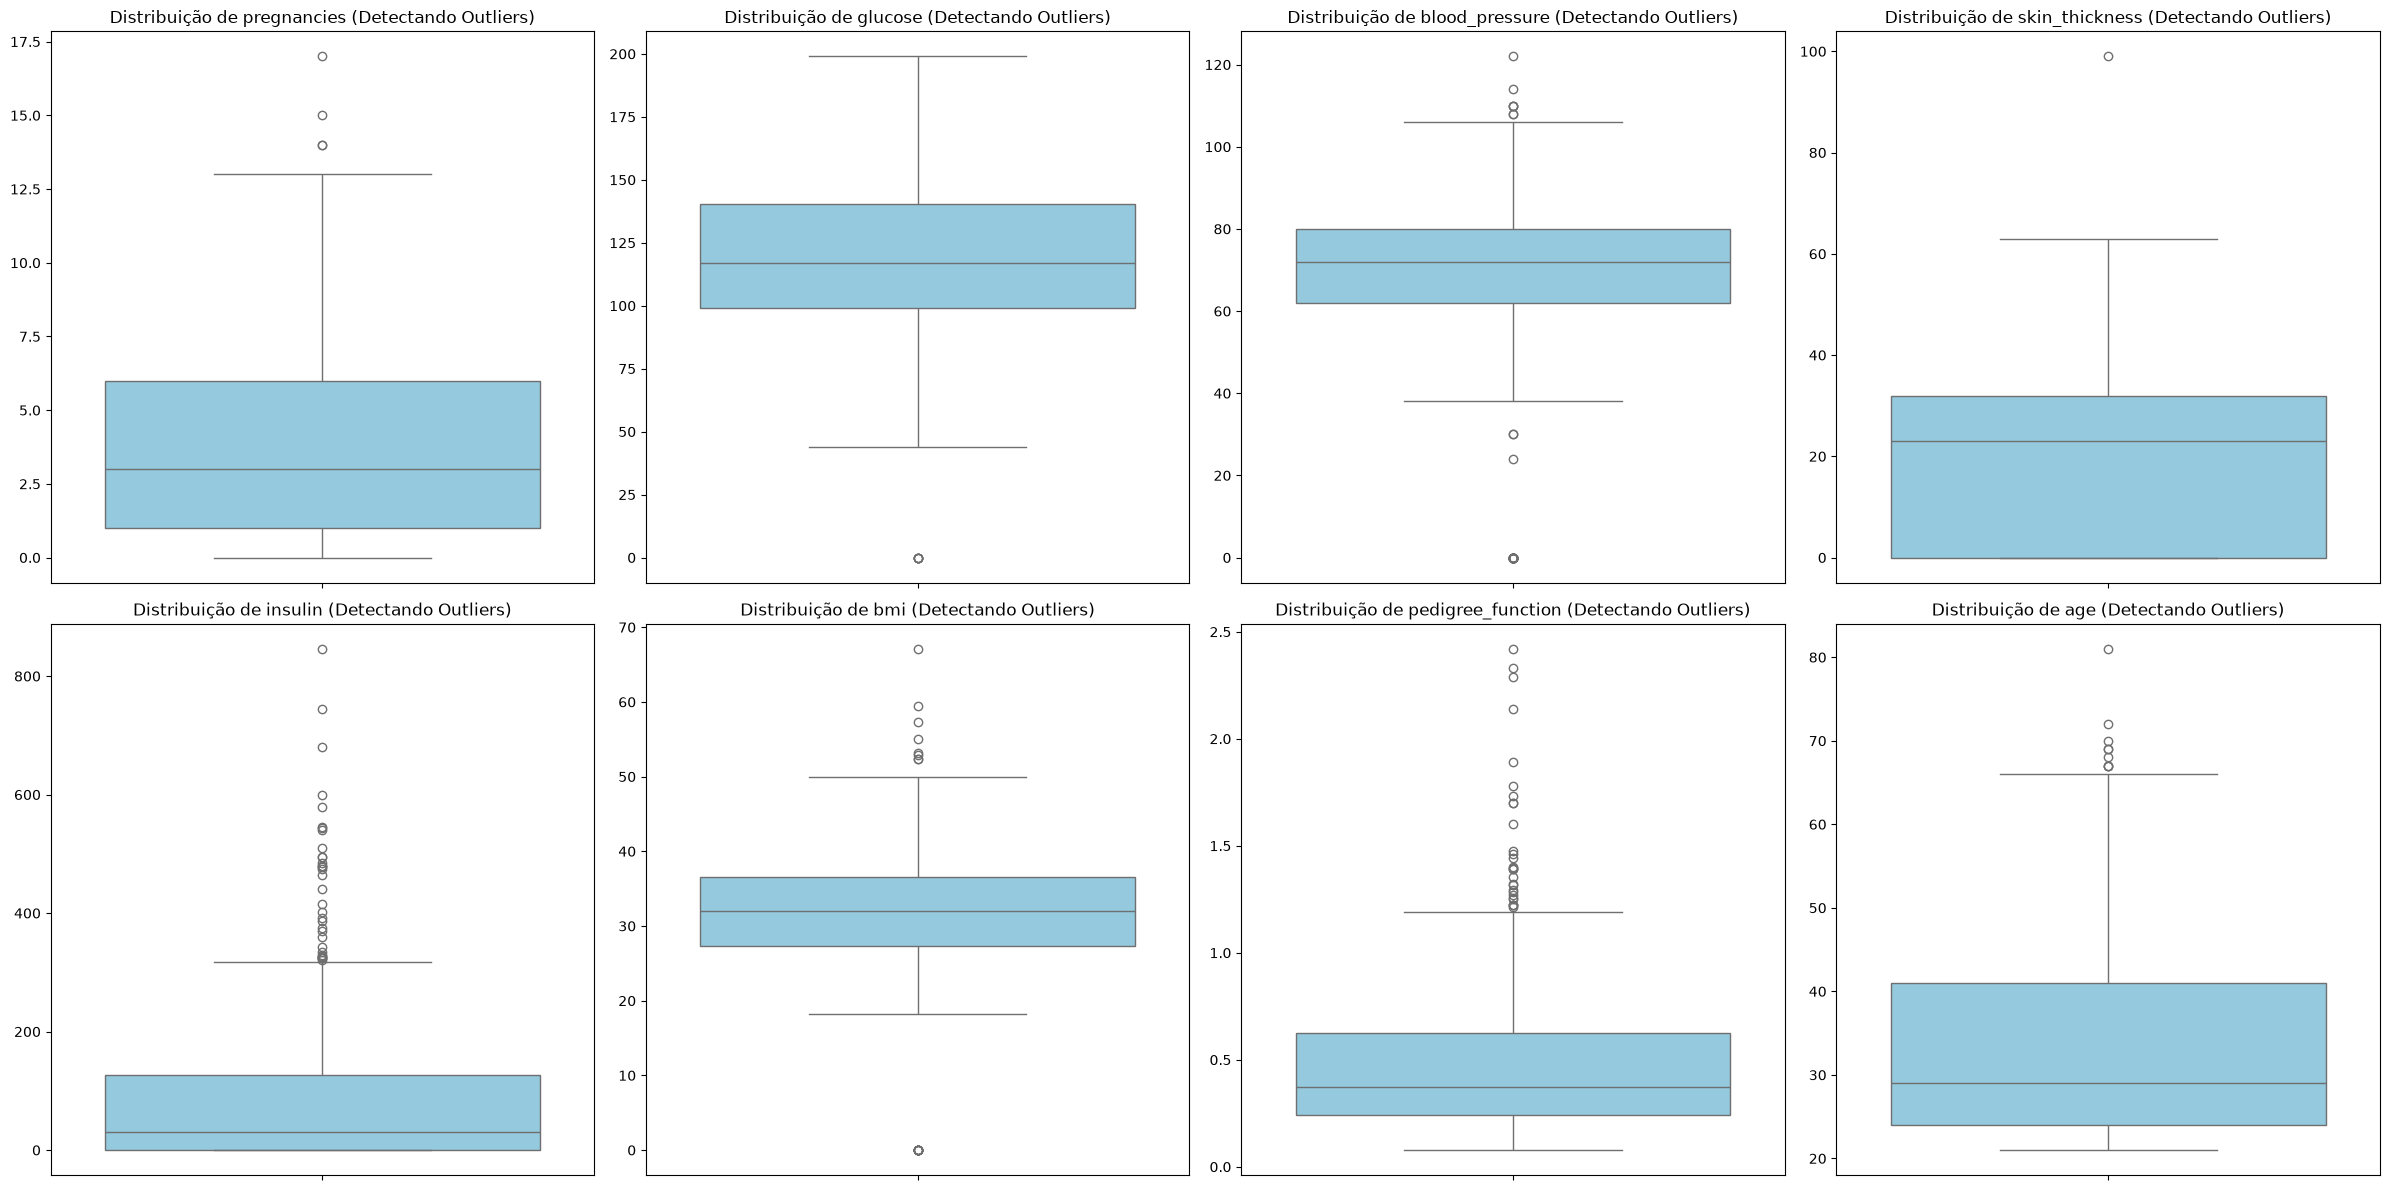

In [213]:
fig, axes = plt.subplots(2, 4, figsize=(24, 12))
axes = axes.flatten()

for i, col in enumerate(df.drop(columns=["diabetes"]).columns):
    sns.boxplot(data=df, y=col, ax=axes[i], color="skyblue")
    axes[i].set_title(f"Distribuição de {col} (Detectando Outliers)")
    axes[i].set_ylabel("")

plt.tight_layout()
plt.show()

### Tratamento de Missing Values


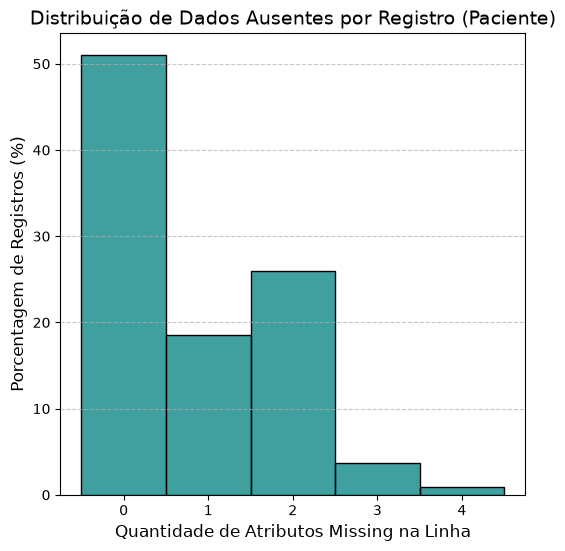

In [214]:
df_nan = df.copy()

for col in ["glucose", "blood_pressure", "skin_thickness", "insulin", "bmi"]:
    df_nan[col] = df_nan[col].replace(0, np.nan)

missing_per_row = df_nan.isna().sum(axis=1)

plt.figure(figsize=(6, 6))
sns.histplot(
    missing_per_row,
    stat="percent",
    discrete=True,
    color="teal",
    edgecolor="black",
    kde=False,
)
plt.title("Distribuição de Dados Ausentes por Registro (Paciente)", fontsize=14)
plt.xlabel("Quantidade de Atributos Missing na Linha", fontsize=12)
plt.ylabel("Porcentagem de Registros (%)", fontsize=12)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

## Modelagem Preditiva


### Estruturação do Pipeline de Experimentação e Avaliação (run_MLP)


In [215]:
def run_MLP(
    df, name, impute_strategy=None, normalize=False, param_grid=None, cv_splits=5
):
    print("=" * 70)
    print(f"EXECUTANDO: {name.upper()}")
    print("=" * 70)

    X = df.drop(columns=["diabetes"])
    y = df["diabetes"]

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    steps = []

    if impute_strategy is not None:
        steps.append(("imputer", SimpleImputer(strategy=impute_strategy)))

    if normalize:
        steps.append(("scaler", StandardScaler()))

    steps.append(("mlp", MLPClassifier(max_iter=1500, random_state=42)))

    pipeline = Pipeline(steps)

    cv_strategy = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)

    if param_grid is None:
        print("Rodando MLP com parâmetros padrão no Pipeline...\n")
        best_pipeline = pipeline
        best_pipeline.fit(X_train, y_train)

        y_train_proba = cross_val_predict(
            best_pipeline,
            X_train,
            y_train,
            cv=cv_strategy,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

    else:
        print("Hiperparâmetros Buscados:")
        for key, value in param_grid.items():
            print(f" - {key}: {value}")

        grid_search = GridSearchCV(
            estimator=pipeline,
            param_grid=param_grid,
            cv=cv_strategy,
            scoring="roc_auc",
            return_train_score=True,
            n_jobs=-1,
            verbose=0,
        )
        grid_search.fit(X_train, y_train)

        best_pipeline = grid_search.best_estimator_
        best_idx = grid_search.best_index_

        print("\nMelhores Hiperparâmetros:")
        for key, value in grid_search.best_params_.items():
            print(f" - {key}: {value}")

        print("\nMétricas de Validação Cruzada (Média do CV):")
        print(
            f" - Train ROC-AUC (CV): {grid_search.cv_results_['mean_train_score'][best_idx]:.4f}"
        )
        print(
            f" - Val ROC-AUC (CV):   {grid_search.cv_results_['mean_test_score'][best_idx]:.4f}\n"
        )

        y_train_proba = cross_val_predict(
            best_pipeline,
            X_train,
            y_train,
            cv=cv_strategy,
            method="predict_proba",
            n_jobs=-1,
        )[:, 1]

    thresholds = np.linspace(0.01, 0.99, 100)
    f1_scores_train = [
        f1_score(y_train, (y_train_proba >= thresh).astype(int), zero_division=0)
        for thresh in thresholds
    ]

    best_threshold = thresholds[np.argmax(f1_scores_train)]

    y_proba = best_pipeline.predict_proba(X_test)[:, 1]

    f1_default_test = f1_score(y_test, (y_proba >= 0.5).astype(int), zero_division=0)
    f1_opt_test = f1_score(
        y_test, (y_proba >= best_threshold).astype(int), zero_division=0
    )

    print(f"Threshold Padrão (0.50) -> F1-Score (Teste): {f1_default_test:.4f}")
    print(
        f"Threshold Otimizado ({best_threshold:.2f}) -> F1-Score (Teste): {f1_opt_test:.4f}\n"
    )

    y_pred_opt = (y_proba >= best_threshold).astype(int)

    accuracy = accuracy_score(y_test, y_pred_opt)
    precision = precision_score(y_test, y_pred_opt, zero_division=0)
    recall = recall_score(y_test, y_pred_opt, zero_division=0)
    f1 = f1_score(y_test, y_pred_opt, zero_division=0)
    roc_auc = roc_auc_score(y_test, y_proba)

    print("Métricas no Conjunto de Teste:")
    print(f" - Accuracy:  {accuracy:.4f}")
    print(f" - Precision:  {precision:.4f}")
    print(f" - Recall: {recall:.4f}")
    print(f" - F1-Score:  {f1:.4f}")
    print(f" - ROC-AUC:   {roc_auc:.4f}\n")

    print("Relatório de Classificação (Teste):")
    print(
        classification_report(
            y_test, y_pred_opt, target_names=["Saudável (0)", "Diabético (1)"]
        )
    )

    conf_matrix = confusion_matrix(y_test, y_pred_opt)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        conf_matrix,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Saudável", "Diabético"],
        yticklabels=["Saudável", "Diabético"],
    )
    plt.title(f"Matriz de Confusão - {name}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.tight_layout()
    plt.show()

    return best_pipeline, {
        "Acurácia": accuracy,
        "ROC-AUC": roc_auc,
        "F1-Score": f1,
        "Best_Threshold": best_threshold,
    }

### Modelo na Base 0 (Baseline)


EXECUTANDO: BASELINE
Rodando MLP com parâmetros padrão no Pipeline...

Threshold Padrão (0.50) -> F1-Score (Teste): 0.5455
Threshold Otimizado (0.42) -> F1-Score (Teste): 0.6143

Métricas no Conjunto de Teste:
 - Accuracy:  0.6494
 - Precision:  0.5000
 - Recall: 0.7963
 - F1-Score:  0.6143
 - ROC-AUC:   0.7013

Relatório de Classificação (Teste):
               precision    recall  f1-score   support

 Saudável (0)       0.84      0.57      0.68       100
Diabético (1)       0.50      0.80      0.61        54

     accuracy                           0.65       154
    macro avg       0.67      0.68      0.65       154
 weighted avg       0.72      0.65      0.66       154



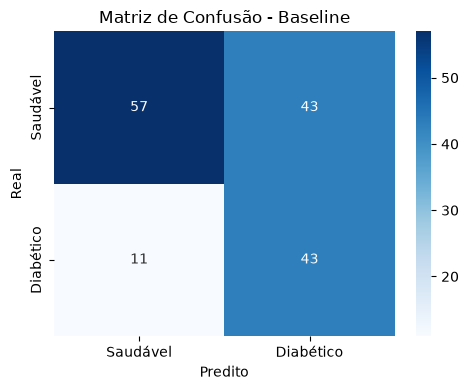

(Pipeline(steps=[('mlp', MLPClassifier(max_iter=1500, random_state=42))]),
 {'Acurácia': 0.6493506493506493,
  'ROC-AUC': 0.7012962962962963,
  'F1-Score': 0.6142857142857143,
  'Best_Threshold': np.float64(0.41585858585858587)})

In [216]:
run_MLP(df, name="Baseline")

### Modelo na Base 1 (Preenchimento de Missing Values)


EXECUTANDO: MLP COM PREENCHIMENTO DE MISSING VALUES
Rodando MLP com parâmetros padrão no Pipeline...

Threshold Padrão (0.50) -> F1-Score (Teste): 0.6929
Threshold Otimizado (0.33) -> F1-Score (Teste): 0.6154

Métricas no Conjunto de Teste:
 - Accuracy:  0.6104
 - Precision:  0.4706
 - Recall: 0.8889
 - F1-Score:  0.6154
 - ROC-AUC:   0.7646

Relatório de Classificação (Teste):
               precision    recall  f1-score   support

 Saudável (0)       0.88      0.46      0.61       100
Diabético (1)       0.47      0.89      0.62        54

     accuracy                           0.61       154
    macro avg       0.68      0.67      0.61       154
 weighted avg       0.74      0.61      0.61       154



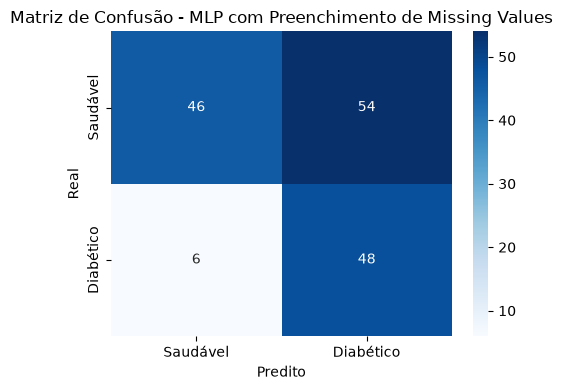

(Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('mlp', MLPClassifier(max_iter=1500, random_state=42))]),
 {'Acurácia': 0.6103896103896104,
  'ROC-AUC': 0.7646296296296297,
  'F1-Score': 0.6153846153846154,
  'Best_Threshold': np.float64(0.32676767676767676)})

In [217]:
run_MLP(
    df_nan, impute_strategy="median", name="MLP com Preenchimento de Missing Values"
)

### Modelo na Base 2 (Preenchimento de Missing Values e Normalização)


EXECUTANDO: MLP COM PREENCHIMENTO DE MISSING VALUES E NORMALIZAÇÃO
Rodando MLP com parâmetros padrão no Pipeline...

Threshold Padrão (0.50) -> F1-Score (Teste): 0.5918
Threshold Otimizado (0.22) -> F1-Score (Teste): 0.6619

Métricas no Conjunto de Teste:
 - Accuracy:  0.6948
 - Precision:  0.5412
 - Recall: 0.8519
 - F1-Score:  0.6619
 - ROC-AUC:   0.8094

Relatório de Classificação (Teste):
               precision    recall  f1-score   support

 Saudável (0)       0.88      0.61      0.72       100
Diabético (1)       0.54      0.85      0.66        54

     accuracy                           0.69       154
    macro avg       0.71      0.73      0.69       154
 weighted avg       0.76      0.69      0.70       154



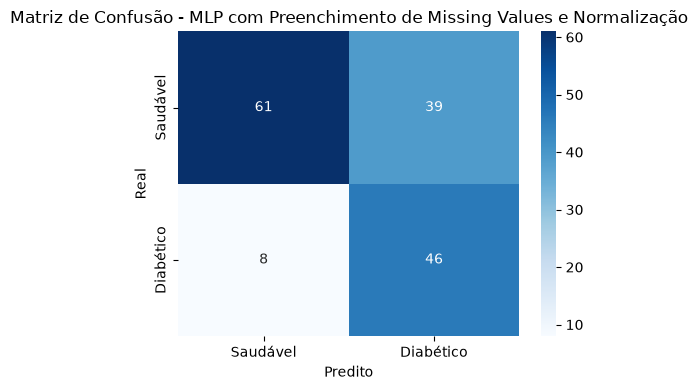

(Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('mlp', MLPClassifier(max_iter=1500, random_state=42))]),
 {'Acurácia': 0.6948051948051948,
  'ROC-AUC': 0.8094444444444444,
  'F1-Score': 0.6618705035971223,
  'Best_Threshold': np.float64(0.21787878787878787)})

In [218]:
run_MLP(
    df_nan,
    impute_strategy="median",
    normalize=True,
    name="MLP com Preenchimento de Missing Values e Normalização",
)

### Otimização de Hiperparâmetros do MLP via Grid Search


#### Avaliação da Arquitetura de Camada Oculta Única


EXECUTANDO: MLP (1 CAMADA) COM HIPERPARÂMETROS OTIMIZADOS
Hiperparâmetros Buscados:
 - mlp__hidden_layer_sizes: [(20,), (25,), (30,)]
 - mlp__activation: ['relu', 'logistic', 'tanh']
 - mlp__alpha: [0.0001, 0.001, 0.01, 0.1]
 - mlp__learning_rate_init: [0.001, 0.01]
 - mlp__max_iter: [1500]

Melhores Hiperparâmetros:
 - mlp__activation: logistic
 - mlp__alpha: 0.01
 - mlp__hidden_layer_sizes: (25,)
 - mlp__learning_rate_init: 0.001
 - mlp__max_iter: 1500

Métricas de Validação Cruzada (Média do CV):
 - Train ROC-AUC (CV): 0.8541
 - Val ROC-AUC (CV):   0.8479

Threshold Padrão (0.50) -> F1-Score (Teste): 0.5490
Threshold Otimizado (0.46) -> F1-Score (Teste): 0.6111

Métricas no Conjunto de Teste:
 - Accuracy:  0.7273
 - Precision:  0.6111
 - Recall: 0.6111
 - F1-Score:  0.6111
 - ROC-AUC:   0.8072

Relatório de Classificação (Teste):
               precision    recall  f1-score   support

 Saudável (0)       0.79      0.79      0.79       100
Diabético (1)       0.61      0.61      0.61

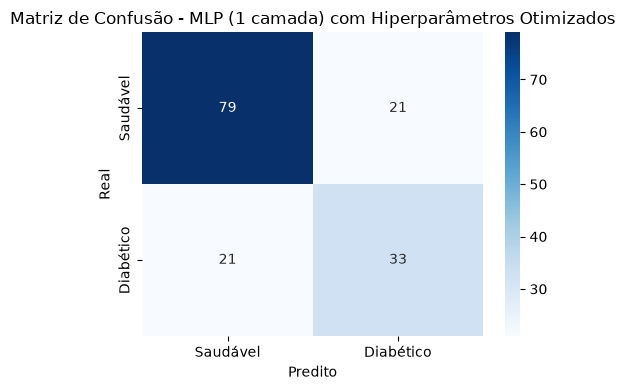

(Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('mlp',
                  MLPClassifier(activation='logistic', alpha=0.01,
                                hidden_layer_sizes=(25,), max_iter=1500,
                                random_state=42))]),
 {'Acurácia': 0.7272727272727273,
  'ROC-AUC': 0.8072222222222222,
  'F1-Score': 0.6111111111111112,
  'Best_Threshold': np.float64(0.45545454545454545)})

In [219]:
param_grid = {
    "mlp__hidden_layer_sizes": [(20,), (25,), (30,)],
    "mlp__activation": ["relu", "logistic", "tanh"],
    "mlp__alpha": [0.0001, 0.001, 0.01, 0.1],
    "mlp__learning_rate_init": [0.001, 0.01],
    "mlp__max_iter": [1500],
}

run_MLP(
    df_nan,
    name="MLP (1 camada) com Hiperparâmetros Otimizados",
    impute_strategy="median",
    normalize=True,
    param_grid=param_grid,
)

#### Avaliação da Arquitetura com Dupla Camada Oculta


EXECUTANDO: MLP (2 CAMADAS) COM HIPERPARÂMETROS OTIMIZADOS
Hiperparâmetros Buscados:
 - mlp__hidden_layer_sizes: [(20, 10), (25, 10), (30, 15), (30, 10)]
 - mlp__activation: ['relu', 'logistic', 'tanh']
 - mlp__alpha: [0.005, 0.01, 0.05]
 - mlp__learning_rate_init: [0.001, 0.01]
 - mlp__max_iter: [1500]

Melhores Hiperparâmetros:
 - mlp__activation: logistic
 - mlp__alpha: 0.01
 - mlp__hidden_layer_sizes: (30, 15)
 - mlp__learning_rate_init: 0.001
 - mlp__max_iter: 1500

Métricas de Validação Cruzada (Média do CV):
 - Train ROC-AUC (CV): 0.8546
 - Val ROC-AUC (CV):   0.8446

Threshold Padrão (0.50) -> F1-Score (Teste): 0.5686
Threshold Otimizado (0.48) -> F1-Score (Teste): 0.6111

Métricas no Conjunto de Teste:
 - Accuracy:  0.7273
 - Precision:  0.6111
 - Recall: 0.6111
 - F1-Score:  0.6111
 - ROC-AUC:   0.8117

Relatório de Classificação (Teste):
               precision    recall  f1-score   support

 Saudável (0)       0.79      0.79      0.79       100
Diabético (1)       0.61    

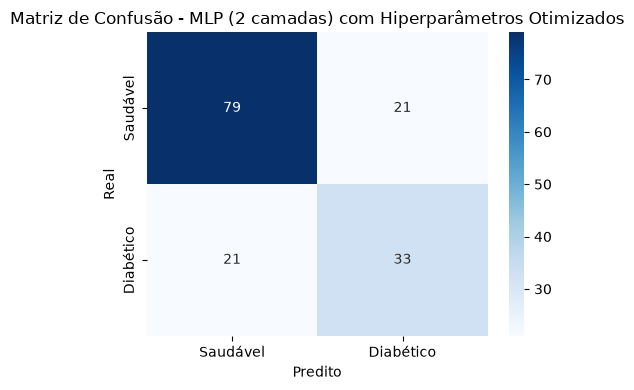

(Pipeline(steps=[('imputer', SimpleImputer(strategy='median')),
                 ('scaler', StandardScaler()),
                 ('mlp',
                  MLPClassifier(activation='logistic', alpha=0.01,
                                hidden_layer_sizes=(30, 15), max_iter=1500,
                                random_state=42))]),
 {'Acurácia': 0.7272727272727273,
  'ROC-AUC': 0.8116666666666666,
  'F1-Score': 0.6111111111111112,
  'Best_Threshold': np.float64(0.47525252525252526)})

In [220]:
param_grid = {
    "mlp__hidden_layer_sizes": [(20, 10), (25, 10), (30, 15), (30, 10)],
    "mlp__activation": ["relu", "logistic", "tanh"],
    "mlp__alpha": [0.005, 0.01, 0.05],
    "mlp__learning_rate_init": [0.001, 0.01],
    "mlp__max_iter": [1500],
}

run_MLP(
    df_nan,
    name="MLP (2 camadas) com Hiperparâmetros Otimizados",
    impute_strategy="median",
    normalize=True,
    param_grid=param_grid,
)